# Linear regression revisited

We revisit the concrete strength regression example under a different perspective, that will be later used for nerual networks. We extensively use PyTorch instead fo NumPy

## Data definition and visualization

A common empirical relationship is that concrete compressive strength decreases as the water-cement ratio increases.
In this notebook, we will simulate experimental lab data of the form:

- $x$ = water-cement ratio  
- $y$ = compressive strength (MPa)

Assuming a linear ground-truth trend $y = 15 - 8x + \text{noise}$, we will estimate this relationship from noisy observations.
Data are defined using Torch tensors

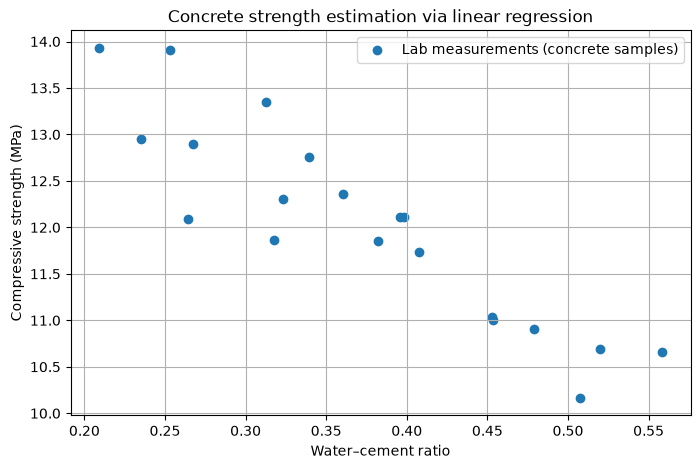

In [108]:
%reset -f

import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0) # set the seed to guarantee reproducibility of results 
N = 20 # Number of data points

# True relationship: strength decreases with higher water content (simplified linear model)
true_params = torch.tensor([15.0, -8.0]) # Intercept, slope
# random generation of water-cement ratio
x = 0.2 + 0.4 * torch.rand(N)

# noisy measurements
y = true_params[0] + true_params[1] * x + 0.5 * torch.randn(N)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Lab measurements (concrete samples)")
#plt.plot(X_test, y_pred, label="Estimated strength model", color="red")
#plt.plot(X_test, y_true, label="True strength model", color="black", linestyle="dashed")
plt.xlabel("Water–cement ratio")
plt.ylabel("Compressive strength (MPa)")
plt.title("Concrete strength estimation via linear regression")
plt.legend()
plt.grid(True)
plt.show()


# Model definition

Our aim is to estimate the unknown parameters $w,b$:
$$
y = w x +b
$$
We will refer to $w$ as weight and to $b$ as bias, a recurrent terminology. We want to compute parameters defining the *best* fitting of the data.

Hence we start defining a function `model` that, given $x$ and an estimate of $w,b$, outputs the predicted $y_p$


In [109]:
def model(x, w, b):
    return w * x + b
    

Let us for instance choose arbitrary values for the weight and the bias and predict $y_p$:

In [110]:
w = torch.ones(()) # w = 1, a zero-order tensor
b = torch.zeros(())  # b = 0, a zero-order tensor

yp = model(x, w, b)
yp


tensor([0.3985, 0.5073, 0.2354, 0.2528, 0.3230, 0.4536, 0.3960, 0.5586, 0.3823,
        0.4529, 0.3396, 0.3607, 0.2089, 0.2675, 0.3176, 0.4074, 0.4791, 0.5200,
        0.2644, 0.3129])

# Loss function
The *distance* between the predicted $y_p$ and the measured values $y$, called *loss* is now computed as:
$$
{\cal L} = MSE = \frac{1}{N} \sum_{i=1}^{N} (y_{pi} - y_i)^2
$$
implemented in function `loss_fn`

In [111]:
def loss_fn(yp, y):
    squared_diffs = (yp - y)**2
    return squared_diffs.mean()
    


Note that `(yp - y)**2` squares each element of the vector individually. This is called element-wise squaring.
If for instance we take the current $y_p$ an $y_m$ we have


In [112]:
loss=loss_fn(yp, y)
loss


tensor(137.2915)

# Loss gradient

We first compute the gradient of the loss function with respect to $w$ and $b$:
$$
\frac{\partial \cal L}{\partial w}=\frac{2}{N}(y_p-y)\cdot y = \frac{2}{N}\sum_i(y_{pi}-y_{i})y_i \qquad
\frac{\partial \cal L}{\partial b}=\frac{2}{N}(y_p-y)\cdot 1= \frac{2}{N}\sum_i(y_{pi}-y_i)
$$



In [113]:
# gradient computing
def grad_fn(yp, y, x, w, b):
    temp = 2*(yp-y)/y.size(0)  # comment 3
    dloss_dw = temp * x   # comment 1
    dloss_db = temp
    return torch.stack([dloss_dw.sum(), dloss_db.sum()])  # comment 2

grad=grad_fn(yp, y, x, w, b)
grad


tensor([ -8.4689, -23.3243])

**Comments**
1. If `a` and `b` are torch 1D tensors then `c=a*b` is the elementwise product, that is a 1D torch tensors with same dimensions having `c[i]=a[i]*b[i]` as elements. On the contrary `torch.dot(a,b)`  is the dot product.
2. `torch.stack` creates a 1D tensor of size 2 starting form 0D tensors (scalars) a and b.
3. In torch when we multiply a 0D tensor (scalar) with a 1D tensor, the result is a 1D tensor where the scalar multiplication has been applied to all the elements. This is a form of *broadcasting*, which is much more general


# Loss minimisation (training)
We’ll optimize the loss function with respect to the parameters using the **gradient descent algorithm**. In this section, we’ll build our intuition for how gradient descent
works from first principles ``params = params - learning_rate * grad ``

It is also wise to change the parameters slowly in general, because the rate of change could be dramatically
different at a distance from the neighborhood of the current w value. Therefore, we typically should scale the rate of change by a small factor. This scaling factor has many names; the one we use in machine learning is learning_rate, e.g. ``learning_rate = 1e-2``

We call a training iteration during which we update the parameters for all of our training samples an ``epoch``


In [114]:
def training_loop(n_epochs, learning_rate, params, y, x) :
    for epoch in range(1, n_epochs + 1):
        w, b = params

        yp = model(x, w, b)  # evaluate the model
        loss = loss_fn(yp, y) # and the loss 
        grad = grad_fn(yp, y, x, w, b)  # and the gradient
        params -= learning_rate * grad  # update the parameters

        print('Epoch %d, Loss %f, w %f, b %f' % (epoch, float(loss), float(params[0]), float(params[1]))) 

    return params    


Let's see what we get with some choices of the input parameters

In [115]:
training_loop(
    n_epochs = 100, 
    learning_rate = 1, 
    params = torch.tensor([-5.0, 10.0]), 
    y = y, 
    x = x)


Epoch 1, Loss 15.561010, w -2.193055, b 17.787334
Epoch 2, Loss 25.107918, w -6.009781, b 7.912067
Epoch 3, Loss 40.733551, w -1.350755, b 20.626389
Epoch 4, Loss 66.303207, w -7.528691, b 4.446472
Epoch 5, Loss 108.140335, w 0.157930, b 25.221821
Epoch 6, Loss 176.589569, w -9.884998, b -1.271191
Epoch 7, Loss 288.573975, w 2.752351, b 32.692211
Epoch 8, Loss 471.778229, w -13.615565, b -10.671429
Epoch 9, Loss 771.492554, w 7.118674, b 44.867413
Epoch 10, Loss 1261.808350, w -19.598518, b -26.094501
Epoch 11, Loss 2063.933105, w 14.379574, b 64.740875
Epoch 12, Loss 3376.153809, w -29.270252, b -51.368942
Epoch 13, Loss 5522.851074, w 26.371788, b 97.209595
Epoch 14, Loss 9034.690430, w -44.980469, b -92.758026
Epoch 15, Loss 14779.794922, w 46.100227, b 150.284653
Epoch 16, Loss 24178.355469, w -70.572983, b -160.508011
Epoch 17, Loss 39553.691406, w 78.480820, b 237.071518
Epoch 18, Loss 64706.570312, w -112.335861, b -271.381042
Epoch 19, Loss 105854.773438, w 131.555756, b 379.00

tensor([-6.2211e+10, -1.6584e+11])

It becomes unstable... Let's decrease the learning rate till we have a stable behaviour.  ``learning_rate = 1e-1`` is an admissible choice, even though convergence is extremely slow

<div style="text-align: center;">
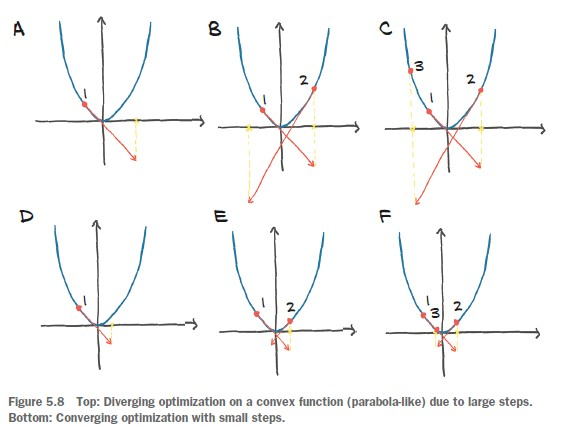
</div>



In [116]:
params=training_loop(
    n_epochs = 1000, 
    learning_rate = .1, 
    params = torch.tensor([-5.0, 10.0]), 
    y = y, 
    x = x)


Epoch 1, Loss 15.561010, w -4.719306, b 10.778733
Epoch 2, Loss 9.489545, w -4.504848, b 11.380840
Epoch 3, Loss 5.869682, w -4.341527, b 11.846574
Epoch 4, Loss 3.711304, w -4.217686, b 12.207012
Epoch 5, Loss 2.424168, w -4.124322, b 12.486151
Epoch 6, Loss 1.656410, w -4.054486, b 12.702518
Epoch 7, Loss 1.198271, w -4.002813, b 12.870416
Epoch 8, Loss 0.924709, w -3.965158, b 13.000891
Epoch 9, Loss 0.761181, w -3.938324, b 13.102469
Epoch 10, Loss 0.663250, w -3.919840, b 13.181737
Epoch 11, Loss 0.604424, w -3.907799, b 13.243776
Epoch 12, Loss 0.568912, w -3.900730, b 13.292512
Epoch 13, Loss 0.547299, w -3.897496, b 13.330975
Epoch 14, Loss 0.533974, w -3.897218, b 13.361504
Epoch 15, Loss 0.525592, w -3.899219, b 13.385906
Epoch 16, Loss 0.520156, w -3.902977, b 13.405578
Epoch 17, Loss 0.516480, w -3.908086, b 13.421594
Epoch 18, Loss 0.513853, w -3.914235, b 13.434787
Epoch 19, Loss 0.511854, w -3.921183, b 13.445799
Epoch 20, Loss 0.510230, w -3.928745, b 13.455126
Epoch 21

**Comments**\
We are using a Python trick called argument unpacking here `*params` means to pass the
elements of params as individual arguments. In Python, this is usually done with lists
or tuples, but we can also use argument unpacking with PyTorch tensors, which are
split along the leading dimension. So here, `model(x, *params)` is equivalent to
`model(x, params[0], params[1])`.

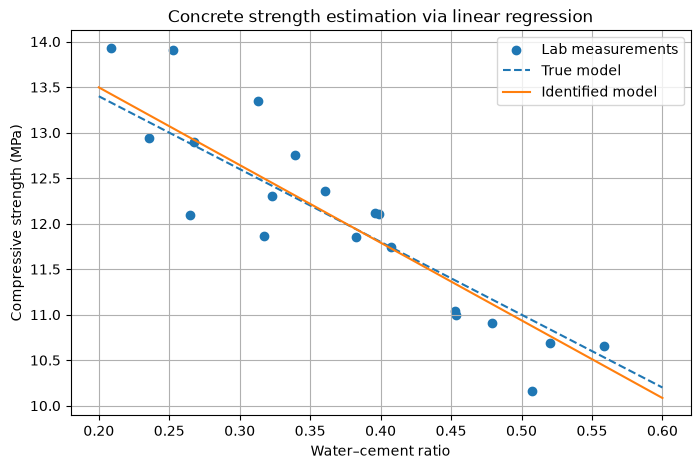

In [117]:
# Points for plotting the lines
x_plot = torch.linspace(0.2, 0.6, 100)
# True model
y_true = model(x_plot, true_params[1], true_params[0])
# Identified model
w, b = params
y_identified = model(x_plot, w, b)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Lab measurements")
plt.plot(x_plot, y_true,label="True model",linestyle="--")
plt.plot(x_plot, y_identified,label="Identified model")
plt.xlabel("Water–cement ratio")
plt.ylabel("Compressive strength (MPa)")
plt.title("Concrete strength estimation via linear regression")
plt.legend()
plt.grid(True)
plt.show()


# PyTorch autograd
PyTorch tensors can remember where they come from, in terms of the operations and parent tensors that originated them, and they can automatically provide the chain of
derivatives of such operations with respect to their inputs. Given a forward expression, no matter how nested,
PyTorch will automatically build a *computation graph* and provide the gradient of that expression with respect to its input parameters.


In [118]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
loss = loss_fn(model(x, *params), y)
loss.backward()
params.grad


tensor([ -8.4689, -23.3243])

**WARNING** Calling `backward` will add to the current gradient. We need to set to zero the gradient explicitly before each call to `backward`

In [119]:
def training_loop(n_epochs, learning_rate, params, y, x):
    for epoch in range(1, n_epochs + 1):
        if params.grad is not None:  # see comments
            params.grad.zero_()
        
        yp = model(x, *params) 
        loss = loss_fn(yp, y)
        loss.backward()
        
        with torch.no_grad():  # <2>
            params -= learning_rate * params.grad

        if epoch % 500 == 0:
          print('Epoch %d, Loss %f, w %f, b %f' 
                        % (epoch, float(loss), float(params[0].detach()), float(params[1].detach()))) 
    

**Comments**\
In PyTorch, every tensor with `requires_grad=True` can have a `.grad` attribute.
Before `backward()`  then `params.grad is None`, while after `loss.backward()`  `params.grad` contains the computed gradients. 
Without `torch.no_grad()`, PyTorch would:
* Track this subtraction
* Add it to the computation graph
* Try to compute gradients through your update step
* Grow the graph every epoch
* Eventually break or explode memory

In [120]:
training_loop(
    n_epochs = 2000, 
    learning_rate = .1, 
    params = torch.tensor([-5.0, 10.0], requires_grad=True), 
    y = y, 
    x = x)


Epoch 500, Loss 0.256065, w -7.095825, b 14.665152
Epoch 1000, Loss 0.206060, w -8.531972, b 15.203880
Epoch 1500, Loss 0.196987, w -9.143740, b 15.433368
Epoch 2000, Loss 0.195340, w -9.404329, b 15.531119


# Default PyTorch Optimizers

We have so far used used vanilla gradient descent for optimization. However, the torch module has an optim submodule where we can find classes implementing different optimization algorithms

In [121]:
import torch.optim as optim
dir(optim)

['ASGD',
 'Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'LBFGS',
 'Muon',
 'NAdam',
 'Optimizer',
 'RAdam',
 'RMSprop',
 'Rprop',
 'SGD',
 'SparseAdam',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_adafactor',
 '_functional',
 '_muon',
 '_stateless',
 'lr_scheduler',
 'swa_utils',
 'swap_in_optimizer_params_and_state']

For instance **SGD** stands for stochastic gradient descent. Actually, the optimizer itself is exactly a
vanilla gradient descent (as long as the momentum argument is set to 0.0, which is the
default). The term stochastic comes from the fact that the gradient is typically obtained
by averaging over a random subset of all input samples, called a minibatch

In [122]:
params = torch.tensor([-5.0,10.0], requires_grad=True)
learning_rate = 1e-1
optimizer = optim.SGD([params], lr=learning_rate)


Now we can define the new `training_loop` module 

In [123]:
def training_loop(n_epochs, optimizer, params, y, x):
    for epoch in range(1, n_epochs + 1):
        
        yp = model(x, *params) 
        loss = loss_fn(yp, y)        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 500 == 0:
          print('Epoch %d, Loss %f, w %f, b %f' 
                        % (epoch, float(loss), float(params[0].detach()), float(params[1].detach()))) 


and launch it:

In [124]:
training_loop(
    n_epochs = 2000, 
    optimizer = optimizer,
    params = params, 
    y = y, 
    x = x)


Epoch 500, Loss 0.256065, w -7.095825, b 14.665152
Epoch 1000, Loss 0.206060, w -8.531972, b 15.203880
Epoch 1500, Loss 0.196987, w -9.143740, b 15.433368
Epoch 2000, Loss 0.195340, w -9.404329, b 15.531119


**Adam** is a more sophisticated optimizer in which the learning rate is set adaptively. In addition, it is a lot less
sensitive to the scaling of the parameters

In [125]:
params = torch.tensor([-5.0,10.0], requires_grad=True)
learning_rate = 1e-1
optimizer = optim.Adam([params], lr=learning_rate) 

training_loop(
    n_epochs = 2000, 
    optimizer = optimizer,
    params = params, 
    y = y, 
    x = x)


Epoch 500, Loss 0.238479, w -7.496135, b 14.806539
Epoch 1000, Loss 0.195174, w -9.456217, b 15.549994
Epoch 1500, Loss 0.194976, w -9.595492, b 15.602820
Epoch 2000, Loss 0.194975, w -9.597669, b 15.603645


# Training set and validation set
If the model we adopt has a large *capacity* which means it can potentially approximate functions of any shape, as in the case of neural networks there is the risk of overfitting. In other words, a highly adaptable model will tend to use its many parameters to make
sure the loss is minimal at the data points, but we’ll have no guarantee that the model behaves well away from or in between the data points. After all, that’s what we’re asking the optimizer to do: minimize the loss at the data points. Sure enough, if we had independent
data points that we didn’t use to evaluate our loss or descend along its negative
gradient, we would soon find out that evaluating the loss at those independent
data points would yield higher-than-expected loss. This phenomenon, called *overfitting*.

<div style="text-align: center;">
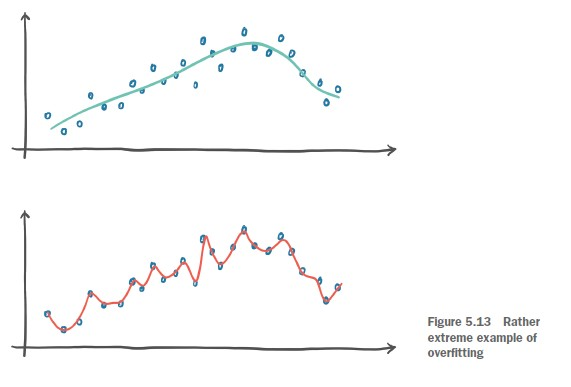
</div>

Assuming we have enough data points, we should make sure the model that is
capable of fitting the training data is as regular as possible in between them. There are
several ways to achieve this. One is adding penalization terms to the loss function, to
make it cheaper for the model to behave more smoothly and change more slowly (up
to a point). Another is to add noise to the input samples, to artificially create new data
points in between training data samples and force the model to try to fit those, too.
There are several other ways, all of them somewhat related to these. But the best favor
we can do to ourselves, at least as a first move, is to make our model simpler. From an
intuitive standpoint, a simpler model may not fit the training data as perfectly as a
more complicated model would, but it will likely behave more regularly in between
data points. 
The first action we can take to combat overfitting is recognizing that it might happen.
In order to do so we must take a few data points out of our dataset (the validation set) and only fit our model on the remaining data
points (the training set). Then, while we’re fitting the model, we can evaluate the loss once on the training set and once on the validation set. When
we’re trying to decide if we’ve done a good job of fitting our model to the data, we must look at both.


In [126]:
n_samples = x.shape[0]
n_val = int(0.2 * n_samples)  # number of elements of the validation set

torch.manual_seed(42)
shuffled_indices = torch.randperm(n_samples)  # shuffling indices by applying a random permutation
val_indices = shuffled_indices[-n_val:]   # last n_val elements
train_indices = shuffled_indices[:-n_val]  # all the rest
print(train_indices)
print(val_indices)

train_x = x[train_indices]
val_x = x[val_indices]
train_y = y[train_indices]
val_y = y[val_indices]
print(train_x)
print(train_y)



tensor([ 2, 14, 18, 15,  1, 10,  0,  4,  6, 11,  8,  3,  7, 17, 13, 12])
tensor([19,  5, 16,  9])
tensor([0.2354, 0.3176, 0.2644, 0.4074, 0.5073, 0.3396, 0.3985, 0.3230, 0.3960,
        0.3607, 0.3823, 0.2528, 0.5586, 0.5200, 0.2675, 0.2089])
tensor([12.9462, 11.8595, 12.0942, 11.7383, 10.1641, 12.7527, 12.1114, 12.3083,
        12.1131, 12.3589, 11.8550, 13.9040, 10.6612, 10.6866, 12.9019, 13.9302])


``shuffled_indices[-n_val:]`` is Python *slicing* and amounts to asking: give me the last n_val elements!
It says: start n_val elements from the end and go until the end of the list

In [127]:
def training_loop(n_epochs, optimizer, params, train_y, val_y, train_x, val_x):
    for epoch in range(1, n_epochs + 1):
        
        train_yp = model(train_x, *params) 
        train_loss = loss_fn(train_yp, train_y)        

        with torch.no_grad(): 
            val_yp = model(val_x, *params) 
            val_loss = loss_fn(val_yp, val_y)        
        
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        if epoch % 500 == 0:
            print(f"Epoch {epoch}, Training loss {train_loss.item():.4f},"
                  f" Validation loss {val_loss.item():.4f}")
            print(params.detach())
            
    
params = torch.tensor([-5.0,10.0], requires_grad=True)
learning_rate = 1e-1
optimizer = optim.Adam([params], lr=learning_rate) 

training_loop(
    n_epochs = 5000, 
    optimizer = optimizer,
    params = params,
    train_y = train_y, 
    val_y = val_y, 
    train_x = train_x, 
    val_x = val_x
)


Epoch 500, Training loss 0.2308, Validation loss 0.3191
tensor([-7.2601, 14.7396])
Epoch 1000, Training loss 0.1979, Validation loss 0.2039
tensor([-8.9468, 15.3580])
Epoch 1500, Training loss 0.1978, Validation loss 0.1986
tensor([-9.0428, 15.3932])
Epoch 2000, Training loss 0.1978, Validation loss 0.1986
tensor([-9.0438, 15.3935])
Epoch 2500, Training loss 0.1978, Validation loss 0.1986
tensor([-9.0438, 15.3935])
Epoch 3000, Training loss 0.1978, Validation loss 0.1986
tensor([-9.0439, 15.3935])
Epoch 3500, Training loss 0.1978, Validation loss 0.1986
tensor([-9.0439, 15.3935])
Epoch 4000, Training loss 0.1978, Validation loss 0.1986
tensor([-9.0439, 15.3936])
Epoch 4500, Training loss 0.1978, Validation loss 0.1986
tensor([-9.0439, 15.3936])
Epoch 5000, Training loss 0.1978, Validation loss 0.1986
tensor([-9.0439, 15.3936])


The validation set is really small, so
the validation loss will only be meaningful up to a point. In any case, we note that the
validation loss is higher than our training loss, although not by an order of magnitude.
We expect a model to perform better on the training set, since the model
parameters are being shaped by the training set. Our main goal is to also see both the
training loss and the validation loss decreasing. While ideally both losses would be
roughly the same value, as long as the validation loss stays reasonably close to the
training loss, we know that our model is continuing to learn generalized things about
our data. In figure 5.14, case C is ideal, while D is acceptable. In case A, the model
isn’t learning at all; and in case B, we see overfitting

<div style="text-align: center;">
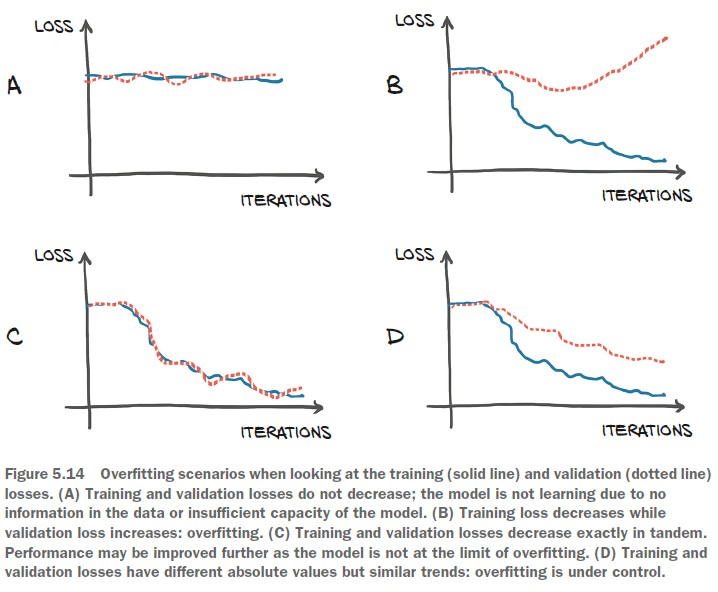
</div>


The only tensors these two graphs have in common are the parameters. When we call
backward on train_loss, we run backward on the first graph. In other words, we
accumulate the derivatives of train_loss with respect to the parameters based on the
computation generated from train_t_u.
If we (incorrectly) called backward on val_loss as well, we would accumulate the
derivatives of val_loss with respect to the parameters on the same leaf nodes

However using `with torch.no_grad()` one can explicitely avoid the creation of the graph


# Exercise
Redefine the model to be $w_2 x^2 + w_1 x + b$.
1. What parts of the training loop, and so on, need to change to accommodate
this redefinition?
2. What parts are insensitive to the change of the model?
3. Is the resulting loss higher or lower after training?
4. Is the actual result better or worse?